# EIS Full-Disk Tutorial

End-to-end pipeline for Hinode/EIS:

1. Search EIS files in a time window using SunPy's `Fido` (with the `EISClient` provided by `eispac.net`).
2. Download the matching HDF5 files (or fall back to a local cache when offline).
3. Fit a spectral line.
4. Build raster SunPy maps (intensity / velocity / non-thermal velocity).
5. Calibrate the intensity maps.
6. Assemble full-disk maps with and without differential rotation.

Set `SAVE_OUTPUTS = True` to save fit and map products to disk and have the final section demonstrate reloading them.

Map plotting relies on SunPy's WCSAxes: `fig.add_subplot(projection=map_obj)` uses CDELT1/CDELT2 from the map's WCS, so the rectangular EIS pixel aspect is handled automatically.

## 1. Configuration

In [1]:
from datetime import datetime
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt

ip = globals().get('get_ipython', lambda: None)()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

repo_root = Path.cwd()
if not (repo_root / 'eismaps').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import eismaps

# --- User configuration ---
SAVE_OUTPUTS = False  # True to save fit + map products to disk and demo reloading.

WORK_ROOT = Path(os.environ.get('EISMAPS_TUTORIAL_WORK_ROOT', Path.home() / 'eismaps_tutorial' / 'full_disk_tutorial'))
RAW_DIR = WORK_ROOT / 'raw_hdf5'
FIT_DIR = WORK_ROOT / 'fits'
MAP_DIR = WORK_ROOT / 'maps'
FULLDISK_DIR = WORK_ROOT / 'full_disk'

START = '2013-01-16 00:00:00'
END = '2013-01-18 23:59:59'
LINE_ID = 'fe_12_195_119'
NCPU = 'max'

for d in (RAW_DIR, FIT_DIR, MAP_DIR, FULLDISK_DIR):
    d.mkdir(parents=True, exist_ok=True)

print('Work root      :', WORK_ROOT)
print('Save outputs   :', SAVE_OUTPUTS)
print('Window         :', START, 'to', END)
print('Line           :', LINE_ID)
print('NCPU           :', NCPU)


Work root      : /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial
Save outputs   : False
Window         : 2013-01-16 00:00:00 to 2013-01-18 23:59:59
Line           : fe_12_195_119
NCPU           : max


## 2. Search and download with Fido

EISPAC registers an `EISClient` for SunPy's `Fido`. We ask for the HDF5 data + header files in the requested time range, then fetch them with `Fido.fetch`. With `overwrite=False`, files already present in `RAW_DIR` are returned immediately without re-downloading, so re-running the notebook is fast. If Fido cannot reach NRL (e.g. on an offline HPC compute node), the notebook falls back to any `.data.h5` files already present in `RAW_DIR`.


In [ ]:
from sunpy.net import Fido, attrs as a
import eispac.net  # registers the EISClient with Fido

data_files = []
active_source = None

try:
    results = Fido.search(
        a.Time(START, END),
        a.Instrument('EIS'),
        a.Source('Hinode'),
        a.Provider('MSSL'),
        a.Level('1'),
    )
    n_hits = sum(len(r) for r in results)
    print('Fido search hits:', n_hits)
    if n_hits > 0:
        downloaded = Fido.fetch(results, path=str(RAW_DIR / '{file}'), max_conn=2, overwrite=False)
        if downloaded.errors:
            print('Fetch errors:', downloaded.errors)
        data_files = sorted(Path(p).resolve() for p in downloaded if p.endswith('.data.h5'))
        active_source = 'fido'
except Exception as e:
    print('Fido search/fetch failed:', e)

local_files = [str(p) for p in data_files]
print('Active source :', active_source)
print('Data files    :', len(local_files))
print('First file    :', local_files[0])
print('Last file     :', local_files[-1])


Fido search hits: 27


Files Downloaded:   0%|          | 0/54 [00:00<?, ?file/s]

Active source : fido
Data files    : 27
First file    : /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_093720.data.h5
Last file     : /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130118_104203.data.h5


## 3. Fit the spectral line and build raster maps

When `SAVE_OUTPUTS = True`, fit results and maps are also written to `FIT_DIR` and `MAP_DIR`.

In [3]:
fit_results = eismaps.fit(
    local_files,
    lines_to_fit=[LINE_ID],
    ncpu=NCPU,
    save=SAVE_OUTPUTS,
    output_dir=str(FIT_DIR) if SAVE_OUTPUTS else None,
)

map_products = eismaps.make_maps(
    fit_results,
    measurement=['int', 'vel', 'ntv'],
    ncpu=NCPU,
    save=SAVE_OUTPUTS,
    output_dir=str(MAP_DIR) if SAVE_OUTPUTS else None,
)

def _as_list(product):
    """Normalise a map, MapSequence, or plain list into a flat list of maps."""
    if hasattr(product, 'maps'):
        return list(product.maps)
    if isinstance(product, list):
        return product
    return [product]

int_maps = _as_list(map_products['int'])
vel_maps = _as_list(map_products['vel'])
ntv_maps = _as_list(map_products['ntv'])

print('Intensity maps:', len(int_maps))
print('Velocity maps :', len(vel_maps))
print('NTV maps      :', len(ntv_maps))


Template lines: ['fe_12_195_119', 'fe_12_195_179']
Data file,
   /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_093720.data.h5
Header file,
   /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_093720.head.h5
Found window 3
 + computing fits for 123 exposures, each with 512 spectra
 + running mpfit on 123 cores (of 256)


/gpfs/data/fs70652/jamesm/venvs/solar/lib/python3.11/site-packages/eispac/core/fit_spectra.py:428: RuntimeWarning: invalid value encountered in divide
  rel_err = obs_errs/obs_cent
/gpfs/data/fs70652/jamesm/venvs/solar/lib/python3.11/site-packages/eispac/core/fit_spectra.py:428: RuntimeWarning: invalid value encountered in divide
  rel_err = obs_errs/obs_cent




Finished computing fits!
   runtime : 0:00:04.126917
   61952 spectra fit without issues
   1024 spectra have < 7 good data points
   0 spectra have bad or invalid parameters
Fit complete but not saved.
Template lines: ['fe_12_195_119', 'fe_12_195_179']
Data file,
   /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_104840.data.h5
Header file,
   /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_104840.head.h5
Found window 3
 + computing fits for 123 exposures, each with 512 spectra
 + running mpfit on 123 cores (of 256)
 + working on exposure 120 + working on exposure 002 + working on exposure 003 + working on exposure 006 + working on exposure 008 + working on exposure 010 + working on exposure 015 + working on exposure 016 + working on exposure 017 + working on exposure 018 + working on exposure 020 + working on exposure 021 + working on exposure 023 + working on exposure 024 + working on exposure 025 + working on exposure 

/gpfs/data/fs70652/jamesm/venvs/solar/lib/python3.11/site-packages/eispac/core/fit_spectra.py:428: RuntimeWarning: invalid value encountered in divide
  rel_err = obs_errs/obs_cent
/gpfs/data/fs70652/jamesm/venvs/solar/lib/python3.11/site-packages/eispac/core/fit_spectra.py:428: RuntimeWarning: invalid value encountered in divide
  rel_err = obs_errs/obs_cent




Finished computing fits!
   runtime : 0:00:04.207095
   60928 spectra fit without issues
   2048 spectra have < 7 good data points
   0 spectra have bad or invalid parameters
Fit complete but not saved.
Template lines: ['fe_12_195_119', 'fe_12_195_179']
Data file,
   /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_213443.data.h5
Header file,
   /home/fs70652/jamesm/eismaps_tutorial/full_disk_tutorial/raw_hdf5/eis_20130116_213443.head.h5
Found window 3
 + computing fits for 123 exposures, each with 512 spectra
 + running mpfit on 123 cores (of 256)
 + working on exposure 122 + working on exposure 002 + working on exposure 003 + working on exposure 004 + working on exposure 008 + working on exposure 009 + working on exposure 011 + working on exposure 012 + working on exposure 013 + working on exposure 014 + working on exposure 015 + working on exposure 017 + working on exposure 019 + working on exposure 020 + working on exposure 021 + working on exposure 

...

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Miss

2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Miss

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Miss

2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-05-27 18:38:58 - sunpy - INFO: Miss

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Intensity maps: 27
Velocity maps : 27
NTV maps      : 27


## 4. Plot a sample raster

WCSAxes handles the rectangular EIS pixel aspect automatically via the map's WCS.

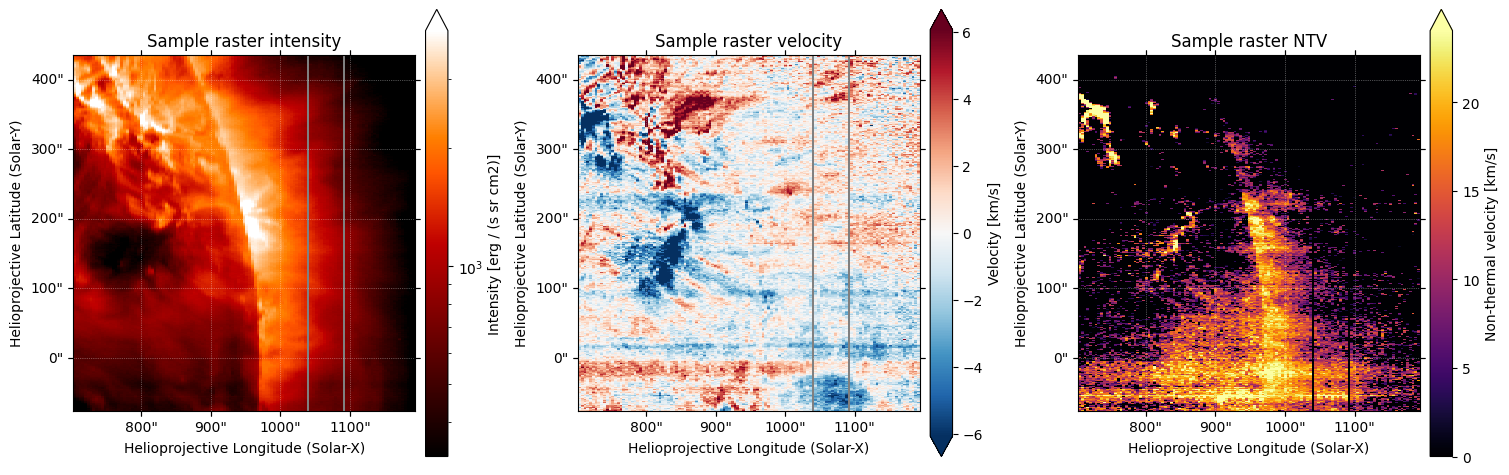

In [4]:
def _cbar_label(m):
    measrmnt = str(m.measurement) if m.measurement is not None else ''
    bunit = m.meta.get('bunit', str(m.unit))
    return f"{measrmnt.capitalize()} [{bunit}]"

sample_int_map = int_maps[0]
sample_vel_map = vel_maps[0]
sample_ntv_map = ntv_maps[0]

fig = plt.figure(figsize=(15, 5), constrained_layout=True)

ax1 = fig.add_subplot(1, 3, 1, projection=sample_int_map)
im1 = sample_int_map.plot(axes=ax1)
ax1.set_title('Sample raster intensity')
plt.colorbar(im1, ax=ax1, pad=0.03, extend='max', label=_cbar_label(sample_int_map))

ax2 = fig.add_subplot(1, 3, 2, projection=sample_vel_map)
im2 = sample_vel_map.plot(axes=ax2)
ax2.set_title('Sample raster velocity')
plt.colorbar(im2, ax=ax2, pad=0.03, extend='both', label=_cbar_label(sample_vel_map))

ax3 = fig.add_subplot(1, 3, 3, projection=sample_ntv_map)
im3 = sample_ntv_map.plot(axes=ax3)
ax3.set_title('Sample raster NTV')
plt.colorbar(im3, ax=ax3, pad=0.03, extend='max', label=_cbar_label(sample_ntv_map))

plt.show()

## 5. Calibrate and assemble full-disk maps

In [8]:
calibrated_int_sequence = eismaps.apply_calibration(
    int_maps,
    method='del_zanna_2025',
    ncpu=NCPU,
)
calibrated_int_maps = _as_list(calibrated_int_sequence)

int_fd_rot, overlap_rot = eismaps.make_helioprojective_map(
    calibrated_int_maps,
    overlap='mean',
    apply_rotation=True,
    preserve_limb=True,
    remove_off_disk=False,
    algorithm='interpolation',
    ncpu=NCPU,
)

int_fd_no_rot, overlap_no_rot = eismaps.make_helioprojective_map(
    calibrated_int_maps,
    overlap='mean',
    apply_rotation=False,
    preserve_limb=True,
    remove_off_disk=False,
    algorithm='interpolation',
    ncpu=NCPU,
)

if SAVE_OUTPUTS:
    int_fd_rot.save(str(FULLDISK_DIR / 'int_fd_rotation_on.fits'), overwrite=True)
    int_fd_no_rot.save(str(FULLDISK_DIR / 'int_fd_rotation_off.fits'), overwrite=True)
    overlap_rot.save(str(FULLDISK_DIR / 'overlap_rotation_on.fits'), overwrite=True)
    print('Saved full-disk products to', FULLDISK_DIR)

print('Full-disk label:', int_fd_rot.meta.get('measrmnt'), '|', int_fd_rot.meta.get('bunit'))
print('Overlap label  :', overlap_rot.meta.get('measrmnt'), '|', overlap_rot.meta.get('bunit'))

Calibration ratio for 195.119 A: [0.91804821] using map date 2013-01-16T14:56:43.000 was applied.
Calibration ratio for 195.119 A: [0.91803872] using map date 2013-01-16T10:48:40.000 was applied.
Calibration ratio for 195.119 A: [0.91804425] using map date 2013-01-16T13:13:13.000 was applied.
Calibration ratio for 195.119 A: [0.91805232] using map date 2013-01-16T16:44:13.000 was applied.
Calibration ratio for 195.119 A: [0.91803599] using map date 2013-01-16T09:37:20.000 was applied.
Calibration ratio for 195.119 A: [0.91807028] using map date 2013-01-17T00:33:42.000 was applied.
Calibration ratio for 195.119 A: [0.91805601] using map date 2013-01-16T18:20:43.000 was applied.
Calibration ratio for 195.119 A: [0.91804153] using map date 2013-01-16T12:02:13.000 was applied.
Calibration ratio for 195.119 A: [0.91806343] using map date 2013-01-16T21:34:43.000 was applied.
Calibration ratio for 195.119 A: [0.91806707] using map date 2013-01-16T23:09:43.000 was applied.
Calibration ratio fo

Processing maps:  96%|█████████████████████████████████████████████▎ | 26/27 [01:28<00:03,  3.57s/it]2026-05-27 18:54:18 - reproject.common - INFO: Calling _reproject_full in non-dask mode


Full-disk label: Intensity (Del Zanna 2025) | erg / (s sr cm2)
Overlap label  : overlap count | count


## 6. Plot the full-disk maps

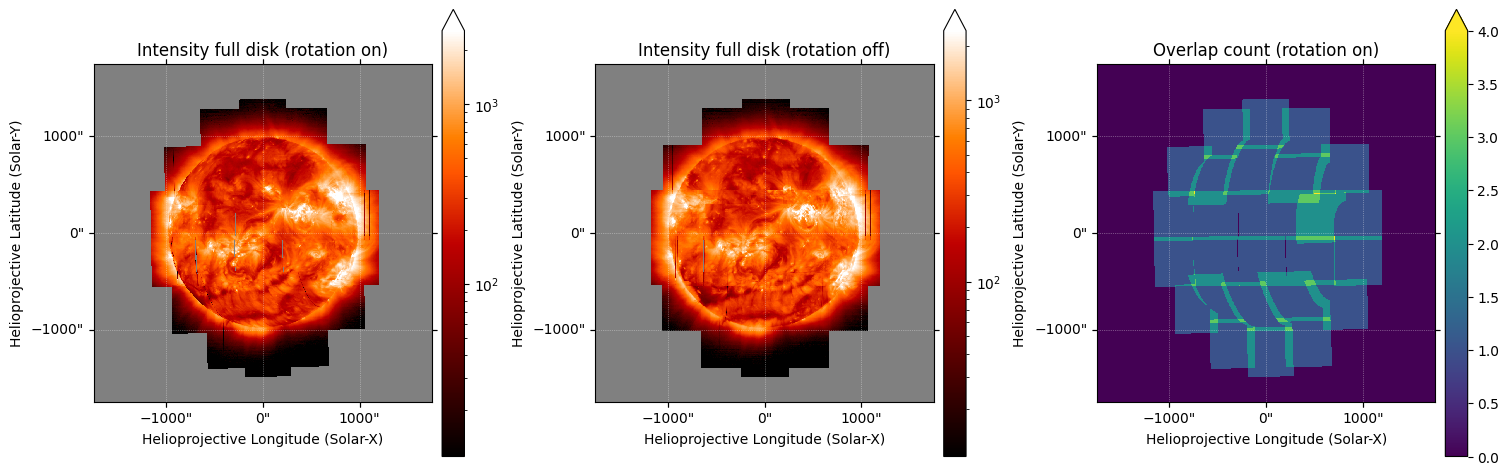

In [9]:
fig = plt.figure(figsize=(15, 5), constrained_layout=True)

ax1 = fig.add_subplot(1, 3, 1, projection=int_fd_rot)
im1 = int_fd_rot.plot(axes=ax1)
ax1.set_title('Intensity full disk (rotation on)')
plt.colorbar(im1, ax=ax1, pad=0.03, extend='max')

ax2 = fig.add_subplot(1, 3, 2, projection=int_fd_no_rot)
im2 = int_fd_no_rot.plot(axes=ax2)
ax2.set_title('Intensity full disk (rotation off)')
plt.colorbar(im2, ax=ax2, pad=0.03, extend='max')

ax3 = fig.add_subplot(1, 3, 3, projection=overlap_rot)
im3 = overlap_rot.plot(axes=ax3)
ax3.set_title('Overlap count (rotation on)')
plt.colorbar(im3, ax=ax3, pad=0.03, extend='max')

plt.show()

## 7. Optional: reload saved products from disk

Runs only when `SAVE_OUTPUTS = True`. The file-based workflow is the same up to step 3, after which you simply read the saved SunPy map FITS files back with `sunpy.map.Map`.

In [ ]:
if SAVE_OUTPUTS:
    import sunpy.map

    fit_files = sorted(FIT_DIR.glob('*.fit.h5'))
    int_map_files = sorted(MAP_DIR.glob('*.int.fits'))
    full_disk_files = sorted(FULLDISK_DIR.glob('*.fits'))

    print('Fit files on disk      :', len(fit_files))
    print('Intensity maps on disk :', len(int_map_files))
    print('Full-disk files on disk:', len(full_disk_files))

    if int_map_files:
        reloaded_raster = sunpy.map.Map(str(int_map_files[0]))
        print('Reloaded raster :', reloaded_raster.meta.get('date_obs'),
              '|', reloaded_raster.meta.get('measrmnt'), '|', reloaded_raster.meta.get('bunit'))
    if full_disk_files:
        reloaded_fd = sunpy.map.Map(str(FULLDISK_DIR / 'int_fd_rotation_on.fits'))
        fig = plt.figure(figsize=(6, 6), constrained_layout=True)
        ax = fig.add_subplot(projection=reloaded_fd)
        im = reloaded_fd.plot(axes=ax)
        ax.set_title('Reloaded full disk (rotation on)')
        plt.colorbar(im, ax=ax, pad=0.03, extend='max')
        plt.show()
else:
    print('SAVE_OUTPUTS is False - skipping reload demo. Set SAVE_OUTPUTS = True in the configuration cell to enable.')